In [2]:
import random
import time
import pandas as pd
from datetime import datetime

sensor_data_log = []
print("--- Starting Live IoT Sensor Data Simulation (10 Readings) --- \n")

#  10 sequential readings from a virtual DHT22/AM2302 sensor
for i in range(10):
    #  timestamp of the reading
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    # temperature usually ranges between 20°C and 35°C
    temperature = round(random.uniform(22.0, 34.0), 2)
    # Relative humidity usually ranges between 45% and 75%
    humidity = round(random.uniform(45.0, 75.0), 2)

    # sensor values in real-time
    print(f"Reading #{i+1} | [{current_time}] Temp: {temperature}°C | Humidity: {humidity}%")

    # Store the data
    sensor_data_log.append({
        "Reading_No": i + 1,
        "Timestamp": current_time,
        "Temperature_C": temperature,
        "Humidity_Percent": humidity
    })

    time.sleep(1.5)
print("\n--- Simulation Complete! Converting logged data to a clean database table... ---")

# list of logs into a structured Pandas DataFrame
df = pd.DataFrame(sensor_data_log)

df

--- Starting Live IoT Sensor Data Simulation (10 Readings) --- 

Reading #1 | [2026-06-28 09:53:08] Temp: 28.66°C | Humidity: 52.97%
Reading #2 | [2026-06-28 09:53:09] Temp: 22.8°C | Humidity: 58.16%
Reading #3 | [2026-06-28 09:53:11] Temp: 26.67°C | Humidity: 64.02%
Reading #4 | [2026-06-28 09:53:12] Temp: 28.6°C | Humidity: 70.11%
Reading #5 | [2026-06-28 09:53:14] Temp: 31.65°C | Humidity: 68.56%
Reading #6 | [2026-06-28 09:53:15] Temp: 22.12°C | Humidity: 48.13%
Reading #7 | [2026-06-28 09:53:17] Temp: 22.26°C | Humidity: 52.18%
Reading #8 | [2026-06-28 09:53:18] Temp: 23.33°C | Humidity: 49.1%
Reading #9 | [2026-06-28 09:53:20] Temp: 32.92°C | Humidity: 74.37%
Reading #10 | [2026-06-28 09:53:21] Temp: 24.35°C | Humidity: 60.97%

--- Simulation Complete! Converting logged data to a clean database table... ---


,Reading_No,Timestamp,Temperature_C,Humidity_Percent
0,1,2026-06-28 09:53:08,28.66,52.97
1,2,2026-06-28 09:53:09,22.80,58.16
2,3,2026-06-28 09:53:11,26.67,64.02
3,4,2026-06-28 09:53:12,28.60,70.11
4,5,2026-06-28 09:53:14,31.65,68.56
5,6,2026-06-28 09:53:15,22.12,48.13
6,7,2026-06-28 09:53:17,22.26,52.18
7,8,2026-06-28 09:53:18,23.33,49.10
8,9,2026-06-28 09:53:20,32.92,74.37
9,10,2026-06-28 09:53:21,24.35,60.97


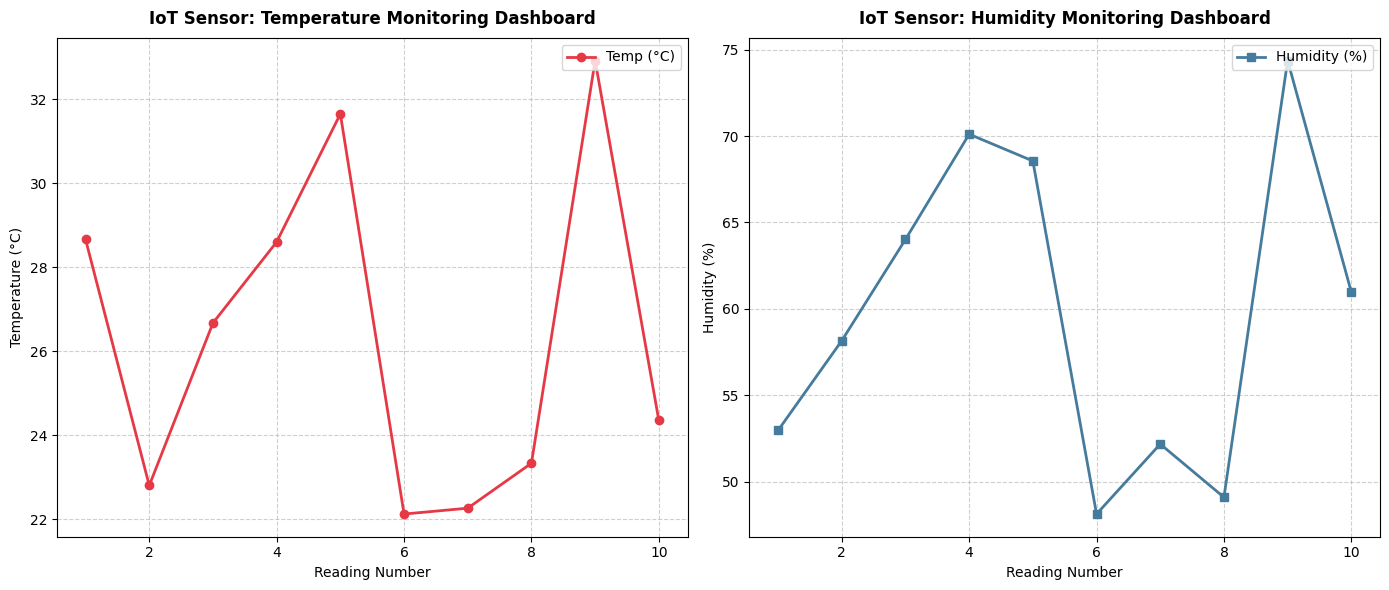

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Temperature Monitoring Line Chart
plt.subplot(1, 2, 1)
plt.plot(df['Reading_No'], df['Temperature_C'], marker='o', linestyle='-', color='#e63946', linewidth=2, label='Temp (°C)')
plt.title('IoT Sensor: Temperature Monitoring Dashboard', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Reading Number', fontsize=10)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

# Humidity Monitoring Line Chart
plt.subplot(1, 2, 2)
plt.plot(df['Reading_No'], df['Humidity_Percent'], marker='s', linestyle='-', color='#457b9d', linewidth=2, label='Humidity (%)')
plt.title('IoT Sensor: Humidity Monitoring Dashboard', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Reading Number', fontsize=10)
plt.ylabel('Humidity (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [6]:
#  safety limit (e.g., 30.0 degrees Celsius)
TEMPERATURE_LIMIT = 30.0
print(f"--- Running Automation & Alert Threshold Monitoring ---")
print(f"Safety Limit Set to: {TEMPERATURE_LIMIT}°C\n")

for index, row in df.iterrows():
    reading_id = int(row['Reading_No'])
    current_temp = row['Temperature_C']

    if current_temp > TEMPERATURE_LIMIT:
        action_triggered = f"🚨 ALERT! High Temp ({current_temp}°C) | Triggering Action: Cooling Fan turned ON."
    else:
        # Normal operations condition
        action_triggered = f"🟢 NORMAL ({current_temp}°C) | Status: Optimal. Cooling Fan remains OFF."

    # 4. Display automation result
    print(f"Reading #{reading_id}: {action_triggered}")

--- Running Automation & Alert Threshold Monitoring ---
Safety Limit Set to: 30.0°C

Reading #1: 🟢 NORMAL (28.66°C) | Status: Optimal. Cooling Fan remains OFF.
Reading #2: 🟢 NORMAL (22.8°C) | Status: Optimal. Cooling Fan remains OFF.
Reading #3: 🟢 NORMAL (26.67°C) | Status: Optimal. Cooling Fan remains OFF.
Reading #4: 🟢 NORMAL (28.6°C) | Status: Optimal. Cooling Fan remains OFF.
Reading #5: 🚨 ALERT! High Temp (31.65°C) | Triggering Action: Cooling Fan turned ON.
Reading #6: 🟢 NORMAL (22.12°C) | Status: Optimal. Cooling Fan remains OFF.
Reading #7: 🟢 NORMAL (22.26°C) | Status: Optimal. Cooling Fan remains OFF.
Reading #8: 🟢 NORMAL (23.33°C) | Status: Optimal. Cooling Fan remains OFF.
Reading #9: 🚨 ALERT! High Temp (32.92°C) | Triggering Action: Cooling Fan turned ON.
Reading #10: 🟢 NORMAL (24.35°C) | Status: Optimal. Cooling Fan remains OFF.
